Price Prediction

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json
from sklearn.preprocessing import MultiLabelBinarizer
data = pd.read_csv('listings.csv.gz')

Turn amenities into binary

In [ ]:
#Parse JSON list
def parse_amenities(x):
    if pd.isna(x):
        return []
    try:
        return json.loads(x)
    except (json.JSONDecodeError, TypeError):
        return []

data["amenities_clean"] = data['amenities'].apply(parse_amenities)

#Create columns for each amenity
mlb = MultiLabelBinarizer()
amenities_df = pd.DataFrame(mlb.fit_transform(data["amenities_clean"]), 
                            columns=[f"{col}" for col in mlb.classes_],
                            index=data.index,)

#For dropping original columns later
dropcols = []

#Group columns with similar keywords together
keywords = {"shampoo" : ["shampoo"],
            "conditioner" : ["conditioner"],
            "body soap" : ["body soap"],
            "oven" : ["oven"],
            "refrigerator" : ["refrigerator"],
            "freezer" : ["freezer"],
            "tv" : ["tv"],
            "cooking untensils" : [ "dishes", "silverware"],
            "stove" : ["stove"],
            "sound system" : ["sound system"],
            "wifi" : ["wifi", "ethernet"],
            "washer" : ["washer"],
            "dryer" : ["dryer"],
            "grill" : ["grill", "barbecue"],
            "baby monitor" : ["baby monitor"],
            "beach" : ["beach"],
            "baby" : ["baby", "crib"],
            "backyard" : ["backyard"],
            "breakfast" : ["breakfast"],
            "air conditioning" : ["air conditioning", "ac", "ceiling fan"],
            "heating" : ["heating"],
            "table" : ["table"],
            "storage" : ["storage"],
            "coffee" : ["coffee"],
            "ev charger" : ["ev charger"],
            "gym" : ["exercise", "weights", "gym"],
            "house keeping" : ["housekeeping"],
            "free parking" : ["free parking", "free carport"],
            "paid parking" : ["paid parking"],
            "hot tub" : ["hot tub"],
            "indoor pool" : ["indoor pool"],
            "private pool" : ["private pool", "private outdoor pool"],
            "shared pool" : ["shared outdoor pool"],
            "ski" : ["ski"],
            "game console" : ["game console"]}

for newcol, keyword in keywords.items():
    matchcols = [col for col in amenities_df.columns
        if any(kw in col.lower() for kw in keyword)]

    amenities_df[newcol] = amenities_df[matchcols].any(axis=1).astype(int)

    dropcols.extend(matchcols)
amenities_df = amenities_df.drop(columns=list(set(dropcols)))

#load data and clean
amenities_df['accommodates'] = data['accommodates']
amenities_df['bedrooms'] = data['bedrooms']
amenities_df['bathrooms'] = data['bathrooms']
amenities_df['latitude'] = data['latitude']
amenities_df['longitude'] = data['longitude']
amenities_df['property_type'] = data['property_type']
amenities_df['review_scores_rating'] = data['review_scores_rating']
amenities_df['reviews_per_month'] = data['reviews_per_month']
amenities_df['hosts_time_as_host'] = data['hosts_time_as_host_years'] * 12 + data['hosts_time_as_host_months']
amenities_df['availability_60'] = data['availability_60']

amenities_df['price'] = data['price']
amenities_df['price'] = amenities_df['price'].str.replace(r'[^\d.]', '', regex=True) # \"^/d means not
amenities_df['price'] = pd.to_numeric(amenities_df['price']).astype(float)

amenities_df['bedrooms'] = amenities_df['bedrooms'].fillna(amenities_df.groupby('accommodates')['bedrooms'].transform('median'))
amenities_df['bathrooms'] = amenities_df['bathrooms'].fillna(amenities_df.groupby('accommodates')['bathrooms'].transform('median'))

amenities_df = pd.get_dummies(amenities_df, columns=['property_type'], drop_first=True, dtype=int)
amenities_df['revenue_per_yr'] = data['estimated_revenue_l365d']
amenities_df['reviews_per_month'] = data['reviews_per_month']

#Drop price outliers
q1 = amenities_df['price'].quantile(0.25)
q3 = amenities_df['price'].quantile(0.75)
iqr = q3 - q1
lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr
amenities_df = amenities_df[(amenities_df['price'] >= lower) & (amenities_df['price'] <= upper)]

amenities_df = amenities_df[(amenities_df['revenue_per_yr'] != 0)]
amenities_df = amenities_df[(amenities_df['reviews_per_month'] != 0)]

amenities_df = amenities_df.dropna() #only hosts time has null values

<function matplotlib.pyplot.show(close=None, block=None)>

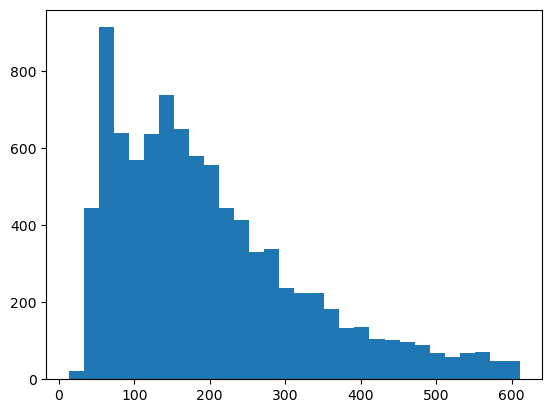

In [4]:
plt.hist(amenities_df['price'], bins=30)
plt.show
#Note data is skewwed right

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.compose import TransformedTargetRegressor
from sklearn.model_selection import train_test_split

X = amenities_df.drop(columns=['price', 'revenue_per_yr'])
y = np.log1p(amenities_df['price']) #price is skewwed right

#train data
Xtrain, Xtest, ytrain, ytest = train_test_split(X, y, train_size=0.2)

#Load model
model = TransformedTargetRegressor(
    regressor=RandomForestRegressor(),
    func=np.log1p, 
    inverse_func=np.expm1)
model.fit(Xtrain, ytrain)

# Calculate the R² score on test data
r2_accuracy = model.score(Xtest, ytest)
print(f"R² Score: {r2_accuracy}")


R² Score: 0.6579160072669454


In [36]:
mdi_importances = model.regressor_.feature_importances_

# Format into a clean DataFrame
features_df = pd.DataFrame({
    'Feature': X.columns.tolist(),
    'Importance': mdi_importances
}).sort_values(by='Importance', ascending=False)

print(features_df)

                                 Feature  Importance
189                         accommodates    0.299345
195                    reviews_per_month    0.135532
193                            longitude    0.101179
197                      availability_60    0.065233
192                             latitude    0.059826
..                                   ...         ...
90                         Mountain view    0.000000
99                          Outdoor pool    0.000000
100  Outdoor pool - available seasonally    0.000000
206         property_type_Entire cottage    0.000000
265                  property_type_Tower    0.000000

[266 rows x 2 columns]
